Nombre total de cohortes (N >= 1) : 5,374
Médiane (P50) : 103 patients
75e percentile : 242 patients
90e percentile : 944 patients
99e percentile : 25236 patients
Effectif max   : 112,042 patients


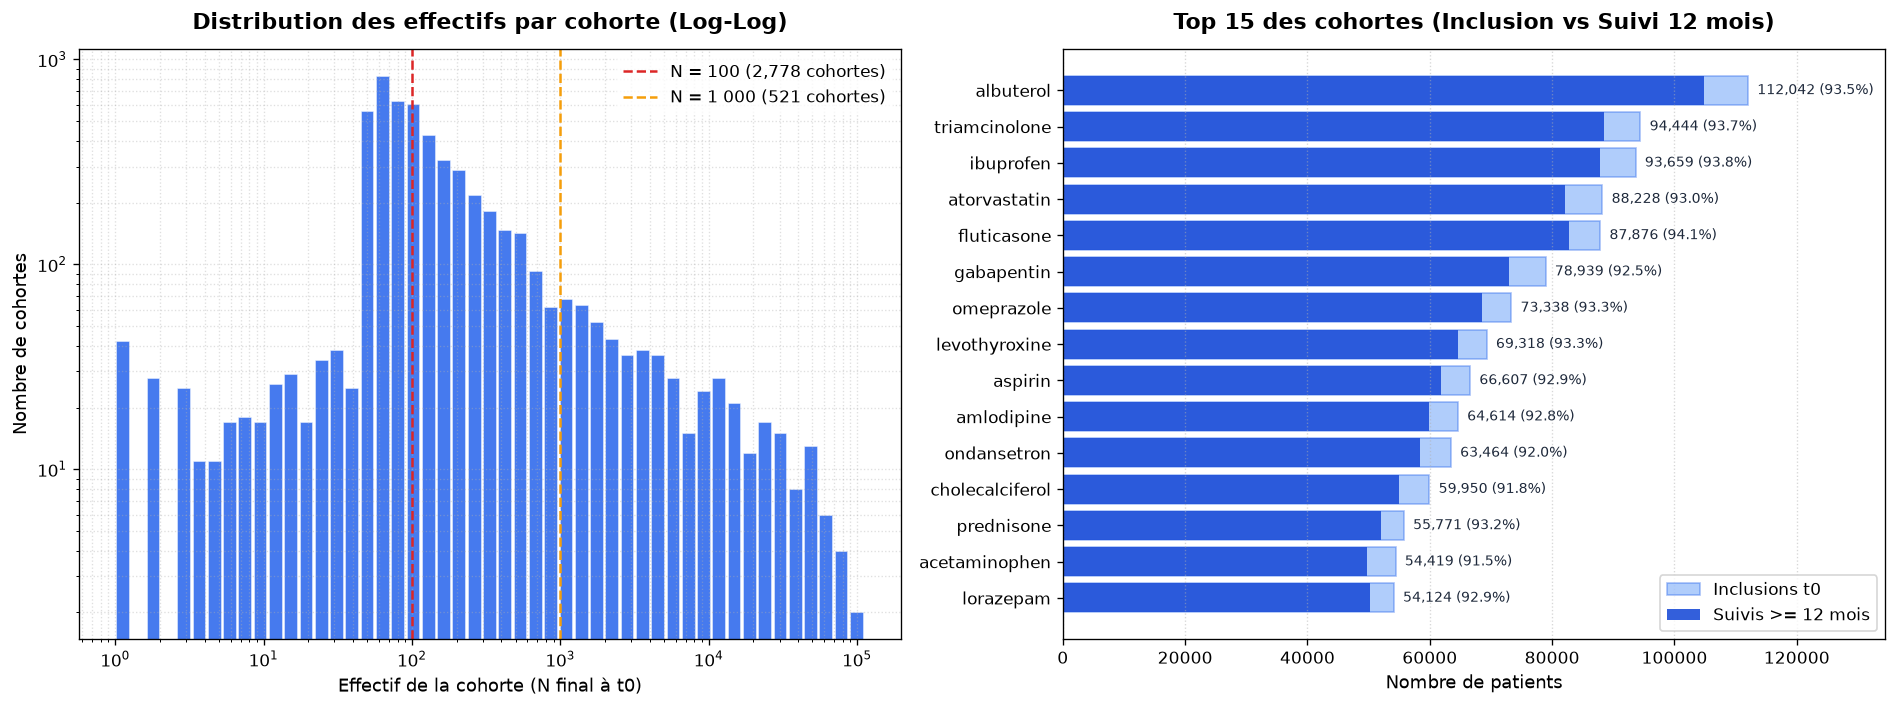

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# 1. Chargement du manifeste
manifest_path = Path("data/cohorts/manifest.parquet")
df = pl.read_parquet(manifest_path).filter(pl.col("n_final_stanford") > 0)

n_total_cohorts = df.height
cohort_sizes = df["n_final_stanford"].to_numpy()

# 2. Statistiques descriptives
p50 = np.percentile(cohort_sizes, 50)
p75 = np.percentile(cohort_sizes, 75)
p90 = np.percentile(cohort_sizes, 90)
p99 = np.percentile(cohort_sizes, 99)

print(f"Nombre total de cohortes (N >= 1) : {n_total_cohorts:,}")
print(f"Médiane (P50) : {p50:.0f} patients")
print(f"75e percentile : {p75:.0f} patients")
print(f"90e percentile : {p90:.0f} patients")
print(f"99e percentile : {p99:.0f} patients")
print(f"Effectif max   : {cohort_sizes.max():,} patients")

# 3. Visualisation double panel
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# Panel 1 : Distribution globale (échelle log)
bins = np.logspace(0, np.log10(cohort_sizes.max()), 50)
ax1.hist(
    cohort_sizes,
    bins=bins,
    color="#2563EB",
    edgecolor="white",
    alpha=0.85,
    rwidth=0.9,
)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.axvline(
    100,
    color="#DC2626",
    linestyle="--",
    linewidth=1.5,
    label=f"N = 100 ({df.filter(pl.col('n_final_stanford') >= 100).height:,} cohortes)",
)
ax1.axvline(
    1000,
    color="#F59E0B",
    linestyle="--",
    linewidth=1.5,
    label=f"N = 1 000 ({df.filter(pl.col('n_final_stanford') >= 1000).height:,} cohortes)",
)

ax1.set_title(
    "Distribution des effectifs par cohorte (Log-Log)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax1.set_xlabel("Effectif de la cohorte (N final à t0)", fontsize=11)
ax1.set_ylabel("Nombre de cohortes", fontsize=11)
ax1.grid(True, which="both", linestyle=":", alpha=0.4)
ax1.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10)

# Panel 2 : Top 15 des cohortes les plus massives
top_15 = (
    df.sort("n_final_stanford", descending=True)
    .head(15)
    .reverse()  # Pour affichage horizontal ascendant
)

y_pos = np.arange(15)
drug_names = top_15["drug_name"].to_list()
sizes = top_15["n_final_stanford"].to_list()
retention_12m = top_15["n_with_12m_followup"].to_list()

bars_total = ax2.barh(
    y_pos,
    sizes,
    color="#3B82F6",
    alpha=0.4,
    edgecolor="#2563EB",
    label="Inclusions t0",
)
bars_12m = ax2.barh(
    y_pos,
    retention_12m,
    color="#1D4ED8",
    alpha=0.9,
    label="Suivis >= 12 mois",
)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(drug_names, fontsize=10)
ax2.set_xlabel("Nombre de patients", fontsize=11)
ax2.set_title(
    "Top 15 des cohortes (Inclusion vs Suivi 12 mois)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax2.grid(axis="x", linestyle=":", alpha=0.5)
ax2.legend(loc="lower right", frameon=True, fontsize=10)

# Annotation des pourcentages de suivi à 12m
for i, (tot, m12) in enumerate(zip(sizes, retention_12m)):
  pct = (m12 / tot) * 100 if tot > 0 else 0
  ax2.text(
      tot + 1500,
      i,
      f"{tot:,} ({pct:.1f}%)",
      va="center",
      fontsize=8.5,
      color="#1E293B",
  )

ax2.set_xlim(0, max(sizes) * 1.2)
plt.tight_layout()
plt.show()

In [1]:
from pathlib import Path
import polars as pl
from src.catalog.catalog import DrugCatalog
from src.config import PathConfig

# 1. Configuration des chemins et du catalogue
paths = PathConfig(is_sample=False)
catalog = DrugCatalog.load(paths.catalog_path)

benchmark_drugs = [
    (1503297, "Metformin"),
    (1545958, "Atorvastatin"),
    (1332418, "Amlodipine"),
    (1367500, "Losartan"),
    (1308216, "Lisinopril"),
]

biomarker_order = ["ldl", "hba1c", "egfr", "alt", "crp", "sbp"]
records = []

# 2. Agrégation des statistiques de complétude et des deltas
for drug_id, default_name in benchmark_drugs:
  item = catalog.get(drug_id)
  drug_name = item.name.upper() if item else default_name.upper()
  cohort_dir = paths.output_cohorts_dir / f"cohort_{drug_id}"

  index_path = cohort_dir / "stanford_index.parquet"
  bio_path = cohort_dir / "biomarkers.parquet"

  if not index_path.exists() or not bio_path.exists():
    print(f"[-] Cohorte manquante : {drug_name} ({drug_id})")
    continue

  n_total = pl.scan_parquet(index_path).select(pl.len()).collect().item()
  df_bio = pl.read_parquet(bio_path)

  for b in biomarker_order:
    sub = df_bio.filter(pl.col("biomarker") == b)
    if sub.height == 0:
      continue

    n_base = sub.filter(pl.col("baseline_val").is_not_null()).height
    n_m6 = sub.filter(pl.col("m6_val").is_not_null()).height
    n_p6 = sub.filter(pl.col("has_pair_6m")).height
    n_p12 = sub.filter(pl.col("has_pair_12m")).height

    base_mean = sub.select(pl.col("baseline_val").mean()).item()
    delta_6m_med = (
        sub.filter(pl.col("has_pair_6m"))
        .select(pl.col("delta_6m").median())
        .item()
    )

    records.append({
        "Molécule": drug_name,
        "N Cohorte": n_total,
        "Biomarqueur": b.upper(),
        "Baseline N (%)": f"{n_base:,} ({n_base/n_total*100:.1f}%)",
        "Suivi 6m N (%)": f"{n_m6:,} ({n_m6/n_total*100:.1f}%)",
        "Paires 6m N (%)": f"{n_p6:,} ({n_p6/n_total*100:.1f}%)",
        "Paires 12m N (%)": f"{n_p12:,} ({n_p12/n_total*100:.1f}%)",
        "Baseline (Moy)": f"{base_mean:.1f}" if base_mean is not None else "-",
        "Δ 6m (Médiane)": (
            f"{delta_6m_med:+.1f}" if delta_6m_med is not None else "-"
        ),
    })

# 3. Affichage du tableau formaté
summary_df = pl.DataFrame(records)

summary_df

Molécule,N Cohorte,Biomarqueur,Baseline N (%),Suivi 6m N (%),Paires 6m N (%),Paires 12m N (%),Baseline (Moy),Δ 6m (Médiane)
str,i64,str,str,str,str,str,str,str
"""METFORMIN""",46570,"""LDL""","""5,638 (12.1%)""","""4,058 (8.7%)""","""1,383 (3.0%)""","""1,639 (3.5%)""","""105.0""","""-5.0"""
"""METFORMIN""",46570,"""HBA1C""","""14,852 (31.9%)""","""12,088 (26.0%)""","""6,679 (14.3%)""","""6,115 (13.1%)""","""7.3""","""-0.3"""
"""METFORMIN""",46570,"""EGFR""","""9,003 (19.3%)""","""9,339 (20.1%)""","""3,816 (8.2%)""","""3,605 (7.7%)""","""92.6""","""+0.0"""
"""METFORMIN""",46570,"""ALT""","""11,055 (23.7%)""","""10,185 (21.9%)""","""4,440 (9.5%)""","""4,333 (9.3%)""","""38.1""","""-3.0"""
"""METFORMIN""",46570,"""CRP""","""1,111 (2.4%)""","""1,224 (2.6%)""","""303 (0.7%)""","""238 (0.5%)""","""4.6""","""+0.0"""
…,…,…,…,…,…,…,…,…
"""LISINOPRIL""",44115,"""HBA1C""","""6,683 (15.1%)""","""5,758 (13.1%)""","""2,319 (5.3%)""","""2,278 (5.2%)""","""6.6""","""-0.1"""
"""LISINOPRIL""",44115,"""EGFR""","""7,686 (17.4%)""","""8,554 (19.4%)""","""3,218 (7.3%)""","""3,053 (6.9%)""","""84.4""","""-1.0"""
"""LISINOPRIL""",44115,"""ALT""","""9,541 (21.6%)""","""9,205 (20.9%)""","""3,871 (8.8%)""","""3,763 (8.5%)""","""35.0""","""-1.0"""


In [24]:
all_results = []
biomarkers_all = ["ldl", "hba1c", "egfr", "alt", "crp", "sbp"]

for drug_id, default_name in [
    (1503297, "Metformin"),
    (1545958, "Atorvastatin"),
    (1332418, "Amlodipine"),
    (1367500, "Losartan"),
    (1308216, "Lisinopril"),
]:
  item = catalog.get(drug_id)
  drug_name = item.name.upper() if item else default_name.upper()
  bio_path = paths.output_cohorts_dir / f"cohort_{drug_id}" / "biomarkers.parquet"

  if not bio_path.exists():
    continue

  df_bio = pl.read_parquet(bio_path)

  for b in biomarkers_all:
    sub = df_bio.filter(
        (pl.col("biomarker") == b) & pl.col("has_pair_6m")
    ).select("delta_6m")
    deltas = sub["delta_6m"].drop_nulls().to_numpy()
    n = len(deltas)

    if n < 30:
      continue

    mean_d = np.mean(deltas)
    med_d = np.median(deltas)
    _, pval = stats.wilcoxon(deltas)

    all_results.append({
        "Molécule": drug_name,
        "Biomarqueur": b.upper(),
        "N (6m)": n,
        "Δ Moyen": round(mean_d, 2),
        "Δ Médian": round(med_d, 2),
        "p-val": "< 1e-16" if pval < 1e-16 else f"{pval:.2e}",
        "Significatif (α=0.01)": pval < 0.01,
    })

pl.DataFrame(all_results).sort(["Molécule", "Biomarqueur"])

Molécule,Biomarqueur,N (6m),Δ Moyen,Δ Médian,p-val,Significatif (α=0.01)
str,str,i64,f64,f64,str,f64
"""AMLODIPINE""","""ALT""",7350,-1.87,0.0,"""5.32e-05""",1.0
"""AMLODIPINE""","""CRP""",592,-1.29,0.0,"""5.74e-03""",1.0
"""AMLODIPINE""","""EGFR""",6717,-0.64,0.0,"""3.21e-07""",1.0
"""AMLODIPINE""","""HBA1C""",3537,-0.08,0.0,"""1.76e-04""",1.0
"""AMLODIPINE""","""LDL""",4783,-29.84,-11.0,"""< 1e-16""",1.0
…,…,…,…,…,…,…
"""METFORMIN""","""CRP""",303,-0.92,0.0,"""3.75e-01""",0.0
"""METFORMIN""","""EGFR""",3816,-0.74,0.0,"""1.28e-05""",1.0
"""METFORMIN""","""HBA1C""",6679,-0.76,-0.3,"""< 1e-16""",1.0


In [2]:
from pathlib import Path
import numpy as np
import polars as pl
from scipy import stats
from src.catalog.catalog import DrugCatalog
from src.config import PathConfig

paths = PathConfig(is_sample=False)
catalog = DrugCatalog.load(paths.catalog_path)

# Paires privilégiées : molécule -> biomarqueur d'indication primaire
primary_targets = [
    (1545958, "Atorvastatin", "ldl", "mg/dL"),
    (1503297, "Metformin", "hba1c", "%"),
    (1332418, "Amlodipine", "sbp", "mmHg"),
    (1367500, "Losartan", "sbp", "mmHg"),
    (1308216, "Lisinopril", "sbp", "mmHg"),
]

results = []

for drug_id, default_name, b_key, unit in primary_targets:
  item = catalog.get(drug_id)
  drug_name = item.name.upper() if item else default_name.upper()
  bio_path = paths.output_cohorts_dir / f"cohort_{drug_id}" / "biomarkers.parquet"

  if not bio_path.exists():
    continue

  df_bio = pl.read_parquet(bio_path)

  # Analyse pour 6 mois et 12 mois
  for horizon, flag_col, delta_col in [
      ("6 mois", "has_pair_6m", "delta_6m"),
      ("12 mois", "has_pair_12m", "delta_12m"),
  ]:
    sub = df_bio.filter(
        (pl.col("biomarker") == b_key) & pl.col(flag_col)
    ).select(["baseline_val", delta_col])

    deltas = sub[delta_col].drop_nulls().to_numpy()
    baselines = sub["baseline_val"].drop_nulls().to_numpy()
    n = len(deltas)

    if n < 10:
      continue

    # 1. Statistiques descriptives
    mean_delta = np.mean(deltas)
    std_delta = np.std(deltas, ddof=1)
    sem_delta = std_delta / np.sqrt(n)
    ci95_low = mean_delta - 1.96 * sem_delta
    ci95_high = mean_delta + 1.96 * sem_delta

    median_delta = np.median(deltas)
    q25, q75 = np.percentile(deltas, [25, 75])

    # 2. Tests d'hypothèse bilatéraux (H0 : delta = 0)
    # Test paramétrique : Student apparié
    t_stat, t_pval = stats.ttest_1samp(deltas, popmean=0.0)

    # Test non-paramétrique : Wilcoxon signed-rank (robuste aux valeurs aberrantes EHR)
    try:
      w_stat, w_pval = stats.wilcoxon(deltas, alternative="two-sided")
    except ValueError:
      w_pval = np.nan

    # 3. Taille d'effet (Cohen's d apparié)
    cohen_d = mean_delta / std_delta if std_delta > 0 else 0.0

    results.append({
        "Molécule": drug_name,
        "Biomarqueur": f"{b_key.upper()} ({unit})",
        "Horizon": horizon,
        "N paires": n,
        "Baseline Moy (SD)": (
            f"{np.mean(baselines):.1f} (±{np.std(baselines, ddof=1):.1f})"
        ),
        "Δ Médian [IQR]": f"{median_delta:+.1f} [{q25:+.1f}, {q75:+.1f}]",
        "Δ Moyen (IC 95%)": (
            f"{mean_delta:+.2f} [{ci95_low:+.2f}, {ci95_high:+.2f}]"
        ),
        "Cohen's d": f"{cohen_d:+.2f}",
        "p-val (Wilcoxon)": (
            "< 1e-16" if w_pval < 1e-16 else f"{w_pval:.2e}"
        ),
    })

res_df = pl.DataFrame(results)
res_df

Molécule,Biomarqueur,Horizon,N paires,Baseline Moy (SD),Δ Médian [IQR],Δ Moyen (IC 95%),Cohen's d,p-val (Wilcoxon)
str,str,str,i64,str,str,str,str,str
"""ATORVASTATIN""","""LDL (mg/dL)""","""6 mois""",3882,"""138.5 (±41.2)""","""-48.0 [-71.0, -17.0]""","""-45.19 [-46.43, -43.95]""","""-1.15""","""< 1e-16"""
"""ATORVASTATIN""","""LDL (mg/dL)""","""12 mois""",4019,"""136.5 (±40.6)""","""-43.0 [-68.0, -13.0]""","""-41.57 [-42.78, -40.36]""","""-1.06""","""< 1e-16"""
"""METFORMIN""","""HBA1C (%)""","""6 mois""",6679,"""7.5 (±1.8)""","""-0.3 [-1.0, +0.0]""","""-0.76 [-0.80, -0.72]""","""-0.46""","""< 1e-16"""
"""METFORMIN""","""HBA1C (%)""","""12 mois""",6115,"""7.4 (±1.8)""","""-0.3 [-1.0, +0.1]""","""-0.67 [-0.72, -0.63]""","""-0.41""","""< 1e-16"""
"""AMLODIPINE""","""SBP (mmHg)""","""6 mois""",19079,"""143.6 (±20.3)""","""-10.0 [-24.0, +3.0]""","""-10.38 [-10.69, -10.07]""","""-0.47""","""< 1e-16"""
"""AMLODIPINE""","""SBP (mmHg)""","""12 mois""",17012,"""143.8 (±20.2)""","""-11.0 [-25.0, +3.0]""","""-10.78 [-11.12, -10.45]""","""-0.49""","""< 1e-16"""
"""LOSARTAN""","""SBP (mmHg)""","""6 mois""",14454,"""137.7 (±19.2)""","""-5.0 [-18.0, +8.0]""","""-4.87 [-5.20, -4.53]""","""-0.24""","""< 1e-16"""
"""LOSARTAN""","""SBP (mmHg)""","""12 mois""",13038,"""137.7 (±19.0)""","""-5.0 [-18.0, +8.0]""","""-5.23 [-5.58, -4.88]""","""-0.26""","""< 1e-16"""
"""LISINOPRIL""","""SBP (mmHg)""","""6 mois""",11491,"""138.6 (±19.9)""","""-8.0 [-20.0, +5.0]""","""-7.77 [-8.15, -7.39]""","""-0.38""","""< 1e-16"""


In [3]:
all_results = []
biomarkers_all = ["ldl", "hba1c", "egfr", "alt", "crp", "sbp"]

for drug_id, default_name in [
    (1503297, "Metformin"),
    (1545958, "Atorvastatin"),
    (1332418, "Amlodipine"),
    (1367500, "Losartan"),
    (1308216, "Lisinopril"),
]:
  item = catalog.get(drug_id)
  drug_name = item.name.upper() if item else default_name.upper()
  bio_path = paths.output_cohorts_dir / f"cohort_{drug_id}" / "biomarkers.parquet"

  if not bio_path.exists():
    continue

  df_bio = pl.read_parquet(bio_path)

  for b in biomarkers_all:
    sub = df_bio.filter(
        (pl.col("biomarker") == b) & pl.col("has_pair_6m")
    ).select("delta_6m")
    deltas = sub["delta_6m"].drop_nulls().to_numpy()
    n = len(deltas)

    if n < 30:
      continue

    mean_d = np.mean(deltas)
    med_d = np.median(deltas)
    _, pval = stats.wilcoxon(deltas)

    all_results.append({
        "Molécule": drug_name,
        "Biomarqueur": b.upper(),
        "N (6m)": n,
        "Δ Moyen": round(mean_d, 2),
        "Δ Médian": round(med_d, 2),
        "p-val": "< 1e-16" if pval < 1e-16 else f"{pval:.2e}",
        "Significatif (α=0.01)": pval < 0.01,
    })

pl.DataFrame(all_results).sort(["Molécule", "Biomarqueur"])

Molécule,Biomarqueur,N (6m),Δ Moyen,Δ Médian,p-val,Significatif (α=0.01)
str,str,i64,f64,f64,str,f64
"""AMLODIPINE""","""ALT""",7350,-2.08,0.0,"""4.09e-05""",1.0
"""AMLODIPINE""","""CRP""",592,-1.3,0.0,"""4.13e-03""",1.0
"""AMLODIPINE""","""EGFR""",6717,-0.59,0.0,"""1.05e-06""",1.0
"""AMLODIPINE""","""HBA1C""",3537,-0.08,0.0,"""2.05e-04""",1.0
"""AMLODIPINE""","""LDL""",1158,-6.36,-3.0,"""2.47e-10""",1.0
…,…,…,…,…,…,…
"""METFORMIN""","""CRP""",303,-0.9,0.0,"""4.98e-01""",0.0
"""METFORMIN""","""EGFR""",3816,-0.69,0.0,"""3.67e-05""",1.0
"""METFORMIN""","""HBA1C""",6679,-0.76,-0.3,"""< 1e-16""",1.0


In [7]:
import polars as pl
from src.catalog.catalog import DrugCatalog
from src.cohorts.extractor import CohortExtractor
from src.config import PathConfig, ProtocolConfig

paths = PathConfig(is_sample=False)
protocol = ProtocolConfig()
catalog = DrugCatalog.load("data/catalog/drug_catalog.jsonl")
extractor = CohortExtractor(catalog=catalog, paths=paths, protocol=protocol)

benchmark_drugs = [
    (1503297, "Metformine"),
    (1545958, "Atorvastatine"),
    (1332418, "Amlodipine"),
    (1367500, "Losartan"),
    (1308216, "Lisinopril"),
]

results = []
cohorts = {}

print("=" * 80)
print("BENCHMARK D'EXTRACTION DES COHORTES CLINIQUES (STARR)")
print("=" * 80)

for drug_id, name in benchmark_drugs:
  cohort = extractor.extract_cohort(drug_id)
  if cohort is not None:
    cohorts[name] = cohort
    n_init = cohort.n_stanford
    n_12m = cohort.stanford_index.filter(pl.col("has_12m_followup")).height
    pct_12m = (n_12m / n_init * 100) if n_init > 0 else 0.0

    results.append({
        "Molécule": name,
        "OMOP ID": drug_id,
        "N_final": n_init,
        "Suivi >= 12m": n_12m,
        "Taux rétention 12m (%)": round(pct_12m, 2),
    })

df_bench = pl.DataFrame(results)
print(df_bench)

Chargement du cache OMOP (cache_full) en mémoire DuckDB...
-> Cache DuckDB prêt.
BENCHMARK D'EXTRACTION DES COHORTES CLINIQUES (STARR)
shape: (5, 5)
┌───────────────┬─────────┬─────────┬──────────────┬────────────────────────┐
│ Molécule      ┆ OMOP ID ┆ N_final ┆ Suivi >= 12m ┆ Taux rétention 12m (%) │
│ ---           ┆ ---     ┆ ---     ┆ ---          ┆ ---                    │
│ str           ┆ i64     ┆ i64     ┆ i64          ┆ f64                    │
╞═══════════════╪═════════╪═════════╪══════════════╪════════════════════════╡
│ Metformine    ┆ 1503297 ┆ 46570   ┆ 42918        ┆ 92.16                  │
│ Atorvastatine ┆ 1545958 ┆ 88228   ┆ 82086        ┆ 93.04                  │
│ Amlodipine    ┆ 1332418 ┆ 64614   ┆ 59942        ┆ 92.77                  │
│ Losartan      ┆ 1367500 ┆ 50794   ┆ 46868        ┆ 92.27                  │
│ Lisinopril    ┆ 1308216 ┆ 44115   ┆ 41652        ┆ 94.42                  │
└───────────────┴─────────┴─────────┴──────────────┴───────────────────